# 05 – Train Models

Trains all comparison models (Naive, v_train baseline, OLS, Ridge numeric, Ridge + categorical, LightGBM)
on the `20260314` feature set. Models and results are saved to `data/04_model_outputs/20260314/`.

**Prerequisites:** `03_feature_engineering.ipynb` must have produced `data/03_features/20260314/region_features.parquet`.

In [ ]:
import sys
from pathlib import Path

# Walk up from cwd until we find the backend root (the directory containing src/)
_cwd = Path.cwd()
for _candidate in [_cwd, *_cwd.parents]:
    if (_candidate / 'src').exists():
        _backend = _candidate
        break
else:
    raise RuntimeError('Could not find backend root (directory containing src/)')

if str(_backend) not in sys.path:
    sys.path.insert(0, str(_backend))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import src.paths as PATHS
from src.model.export_utils import save_model_bundle

SEED = 42
EXPERIMENT = '20260314'

## 1. Load features

In [17]:
FEAT_PATH = PATHS.DATA_DIR / '03_features' / EXPERIMENT / 'region_features.parquet'
feat = pd.read_parquet(FEAT_PATH)

train = feat[feat['split'] == 'train'].copy()
test  = feat[feat['split'] == 'test'].copy()

TARGET = 'v_test'

print(f'Train: {len(train):,}  |  Test: {len(test):,}')
print(f'Target – train  mean={train[TARGET].mean():.3f}  std={train[TARGET].std():.3f}')
print(f'Target – test   mean={test[TARGET].mean():.3f}  std={test[TARGET].std():.3f}')
feat.head(3)

Train: 5,955  |  Test: 1,489
Target – train  mean=0.147  std=2.183
Target – test   mean=0.162  std=2.200


,v_train,v_test,dist_t1,dist_t2,dist_t3,train_span_yr,test_span_yr,is_nvo,river,river_enc,...,drawdown_index_t1,flood_days_t1,n_events_t2,max_rise_rate_t2,drawdown_index_t2,flood_days_t2,bend_exposure_n5,bend_exposure_n8,split,cluster
location_id,,,,,,,,,,,,,,,,,,,,,
ijssel1_l_0010_0020,0.150221,0.166912,155.478645,156.229750,156.730486,5,3,False,ijssel1,5,...,4.375,22.75,2.0,3.690833,3.482917,61.0,-0.000000,-0.000000,train,ijssel1
ijssel1_l_0020_0030,0.016667,-0.055556,168.083333,168.166667,168.000000,5,3,False,ijssel1,5,...,4.375,22.75,2.0,3.690833,3.482917,61.0,0.000223,0.000268,test,ijssel1
ijssel1_l_0050_0056,-0.083333,-0.555556,48.916667,48.500000,46.833333,5,3,False,ijssel1,5,...,4.375,22.75,2.0,3.690833,3.482917,61.0,0.000351,0.000356,train,ijssel1


## 2. Feature sets

In [18]:
FEATS_2 = ['v_train']

FEATS_3 = [
    'v_train', 'dist_t2',
    'train_span_yr', 'test_span_yr',
    'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1',
    'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2',
    'bend_exposure_n5', 'bend_exposure_n8',
]

FEATS_4 = FEATS_3 + [
    'is_nvo', 'river_enc', 'vegetation_class_enc', 'soil_group_enc', 'land_use_enc',
]

FEATS_LGB = [
    'v_train', 'dist_t2',
    'train_span_yr', 'test_span_yr',
    'erosion_vol_rate_t1',
    'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1',
    'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2',
    'bend_exposure_n5', 'bend_exposure_n8',
    'is_nvo', 'river_enc', 'vegetation_class_enc', 'soil_group_enc', 'land_use_enc',
]

CAT_FEATS = ['river_enc', 'vegetation_class_enc', 'soil_group_enc', 'land_use_enc']

print('Feature sets:')
print(f'  FEATS_2  ({len(FEATS_2):>2}): {FEATS_2}')
print(f'  FEATS_3  ({len(FEATS_3):>2}): {FEATS_3}')
print(f'  FEATS_4  ({len(FEATS_4):>2}): {FEATS_4}')
print(f'  FEATS_LGB({len(FEATS_LGB):>2}): {FEATS_LGB}')

Feature sets:
  FEATS_2  ( 1): ['v_train']
  FEATS_3  (14): ['v_train', 'dist_t2', 'train_span_yr', 'test_span_yr', 'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1', 'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2', 'bend_exposure_n5', 'bend_exposure_n8']
  FEATS_4  (19): ['v_train', 'dist_t2', 'train_span_yr', 'test_span_yr', 'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1', 'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2', 'bend_exposure_n5', 'bend_exposure_n8', 'is_nvo', 'river_enc', 'vegetation_class_enc', 'soil_group_enc', 'land_use_enc']
  FEATS_LGB(20): ['v_train', 'dist_t2', 'train_span_yr', 'test_span_yr', 'erosion_vol_rate_t1', 'n_events_t1', 'max_rise_rate_t1', 'drawdown_index_t1', 'flood_days_t1', 'n_events_t2', 'max_rise_rate_t2', 'drawdown_index_t2', 'flood_days_t2', 'bend_exposure_n5', 'bend_exposure_n8', 'is_nvo', 'river_enc', 'vegetation_class_enc', 'soil_group_enc', 'land_use_e

## 3. Evaluation helpers

In [19]:
RESULTS = {}   # keyed by model name
TAIL_THRESHOLD = 2.0  # m/yr — operationally critical regions

def root_mean_squared_error(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Compute metrics and store in RESULTS. MAE primary, RMSE secondary, tail MAE for v > 2 m/yr."""
    y_tr_true = np.asarray(y_train_true)
    y_tr_pred = np.asarray(y_train_pred)
    y_te_true = np.asarray(y_test_true)
    y_te_pred = np.asarray(y_test_pred)

    tr_mask  = y_tr_true > TAIL_THRESHOLD
    te_mask  = y_te_true > TAIL_THRESHOLD
    tr_tail_n = int(tr_mask.sum())
    te_tail_n = int(te_mask.sum())

    row = dict(
        train_rmse    = root_mean_squared_error(y_tr_true, y_tr_pred),
        train_mae     = mean_absolute_error(y_tr_true, y_tr_pred),
        train_r2      = r2_score(y_tr_true, y_tr_pred),
        train_tail_mae= mean_absolute_error(y_tr_true[tr_mask], y_tr_pred[tr_mask]) if tr_tail_n > 0 else float('nan'),
        train_tail_n  = tr_tail_n,
        test_rmse     = root_mean_squared_error(y_te_true, y_te_pred),
        test_mae      = mean_absolute_error(y_te_true, y_te_pred),
        test_r2       = r2_score(y_te_true, y_te_pred),
        test_tail_mae = mean_absolute_error(y_te_true[te_mask], y_te_pred[te_mask]) if te_tail_n > 0 else float('nan'),
        test_tail_n   = te_tail_n,
    )
    RESULTS[name] = row
    print(f"  {'metric':>14}    train       test")
    print(f"  {'MAE (prim)':>14}    {row['train_mae']:.4f}    {row['test_mae']:.4f}")
    print(f"  {'RMSE':>14}    {row['train_rmse']:.4f}    {row['test_rmse']:.4f}")
    print(f"  {'MAE tail>2':>14}    {row['train_tail_mae']:.4f}    {row['test_tail_mae']:.4f}  (train n={tr_tail_n}, test n={te_tail_n})")
    print(f"  {'R²':>14}    {row['train_r2']:.4f}    {row['test_r2']:.4f}")
    return row


def scatter_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    ax.scatter(y_true, y_pred, s=4, alpha=0.3, linewidths=0)
    lim = max(abs(np.array(y_true).max()), abs(np.array(y_pred).max())) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlabel('actual  (m/yr)')
    ax.set_ylabel('predicted  (m/yr)')
    ax.set_title(title, fontsize=9)


def prep_cats(df, cols):
    out = df[cols].copy()
    if 'is_nvo' in out.columns:
        out['is_nvo'] = out['is_nvo'].astype(int)
    return out.astype(float).values


def prep_lgb(df, cols):
    out = df[cols].copy()
    if 'is_nvo' in out.columns:
        out['is_nvo'] = out['is_nvo'].astype(int)
    return out.astype(float)

## 4. Model 0 – Naive mean

In [20]:
global_mean = train[TARGET].mean()
y_train_pred_0 = np.full(len(train), global_mean)
y_test_pred_0  = np.full(len(test),  global_mean)

print('Model 0 – Naive mean')
evaluate('0 – Naive mean', train[TARGET], y_train_pred_0, test[TARGET], y_test_pred_0)

Model 0 – Naive mean
          metric    train       test
      MAE (prim)    0.7976    0.7843
            RMSE    2.1832    2.1993
      MAE tail>2    5.4531    5.5200  (train n=325, test n=78)
              R²    0.0000    -0.0000


{'train_rmse': 2.1831705735995555,
 'train_mae': 0.7976445723665108,
 'train_r2': 0.0,
 'train_tail_mae': 5.453088502913394,
 'train_tail_n': 325,
 'test_rmse': 2.1993368985105737,
 'test_mae': 0.7843354038036506,
 'test_r2': -4.587914477993671e-05,
 'test_tail_mae': 5.519951535740634,
 'test_tail_n': 78}

## 5. Model 1 – v_train baseline

In [21]:
print('Model 1 – v_train baseline')
evaluate('1 – v_train baseline',
         train[TARGET], train['v_train'],
         test[TARGET],  test['v_train'])

Model 1 – v_train baseline
          metric    train       test
      MAE (prim)    1.1562    1.2240
            RMSE    3.0229    3.2509
      MAE tail>2    6.5363    6.9339  (train n=325, test n=78)
              R²    -0.9172    -1.1850


{'train_rmse': 3.0228859606437957,
 'train_mae': 1.1561641172504749,
 'train_r2': -0.9172033944997797,
 'train_tail_mae': 6.536316912804447,
 'train_tail_n': 325,
 'test_rmse': 3.250922760725269,
 'test_mae': 1.224000328465265,
 'test_r2': -1.1849912688810975,
 'test_tail_mae': 6.933881893943115,
 'test_tail_n': 78}

## 6. Model 2 – OLS (v_train only)

In [22]:
ols_vt = LinearRegression()
ols_vt.fit(train[FEATS_2].values, train[TARGET])

print('Model 2 – OLS v_train')
print(f'  coefficient: {ols_vt.coef_[0]:.4f}   intercept: {ols_vt.intercept_:.4f}')
evaluate('2 – OLS v_train',
         train[TARGET], ols_vt.predict(train[FEATS_2].values),
         test[TARGET],  ols_vt.predict(test[FEATS_2].values))

Model 2 – OLS v_train
  coefficient: -0.5739   intercept: 0.2017
          metric    train       test
      MAE (prim)    0.8144    0.8447
            RMSE    2.0239    2.0888
      MAE tail>2    4.9052    4.7493  (train n=325, test n=78)
              R²    0.1406    0.0979


{'train_rmse': 2.0239221993755954,
 'train_mae': 0.8144006626517545,
 'train_r2': 0.1405664763763168,
 'train_tail_mae': 4.905211691871427,
 'train_tail_n': 325,
 'test_rmse': 2.0888482095364402,
 'test_mae': 0.8446531234824964,
 'test_r2': 0.09790937783170128,
 'test_tail_mae': 4.749318752983035,
 'test_tail_n': 78}

## 7. Model 3 – Ridge (numeric features)

In [23]:
ridge_num = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
ridge_num.fit(train[FEATS_3].values, train[TARGET])

print('Model 3 – Ridge numeric')
for f, c in zip(FEATS_3, ridge_num.named_steps['ridge'].coef_):
    print(f'  {f:>26s}: {c:+.4f}')
evaluate('3 – Ridge numeric',
         train[TARGET], ridge_num.predict(train[FEATS_3].values),
         test[TARGET],  ridge_num.predict(test[FEATS_3].values))

Model 3 – Ridge numeric
                     v_train: -0.8038
                     dist_t2: -0.0329
               train_span_yr: +0.0000
                test_span_yr: +0.0440
                 n_events_t1: +0.3838
            max_rise_rate_t1: +0.0554
           drawdown_index_t1: -0.2093
               flood_days_t1: -0.3568
                 n_events_t2: -0.0711
            max_rise_rate_t2: +0.2152
           drawdown_index_t2: -0.2967
               flood_days_t2: -0.2575
            bend_exposure_n5: +0.1401
            bend_exposure_n8: -0.1167
          metric    train       test
      MAE (prim)    0.8440    0.8718
            RMSE    2.0089    2.0733
      MAE tail>2    4.8135    4.6583  (train n=325, test n=78)
              R²    0.1532    0.1113


{'train_rmse': 2.0089385186335904,
 'train_mae': 0.8440011755071257,
 'train_r2': 0.1532446412758297,
 'train_tail_mae': 4.813466574967367,
 'train_tail_n': 325,
 'test_rmse': 2.0732592505854988,
 'test_mae': 0.8717713879472752,
 'test_r2': 0.11132364049640531,
 'test_tail_mae': 4.65830118084027,
 'test_tail_n': 78}

## 8. Model 4 – Ridge (numeric + categorical)

In [24]:
ridge_cat = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
ridge_cat.fit(prep_cats(train, FEATS_4), train[TARGET])

print('Model 4 – Ridge + categorical')
for f, c in zip(FEATS_4, ridge_cat.named_steps['ridge'].coef_):
    print(f'  {f:>30s}: {c:+.4f}')
evaluate('4 – Ridge + categorical',
         train[TARGET], ridge_cat.predict(prep_cats(train, FEATS_4)),
         test[TARGET],  ridge_cat.predict(prep_cats(test,  FEATS_4)))

Model 4 – Ridge + categorical
                         v_train: -0.8018
                         dist_t2: -0.0762
                   train_span_yr: +0.0000
                    test_span_yr: +0.2560
                     n_events_t1: +0.3941
                max_rise_rate_t1: +0.0295
               drawdown_index_t1: -0.1641
                   flood_days_t1: -0.3095
                     n_events_t2: -0.1250
                max_rise_rate_t2: +0.1690
               drawdown_index_t2: -0.2806
                   flood_days_t2: +0.0519
                bend_exposure_n5: +0.1453
                bend_exposure_n8: -0.1170
                          is_nvo: +0.1079
                       river_enc: -0.2090
            vegetation_class_enc: -0.0115
                  soil_group_enc: +0.0901
                    land_use_enc: -0.0286
          metric    train       test
      MAE (prim)    0.8455    0.8717
            RMSE    2.0043    2.0612
      MAE tail>2    4.7901    4.6246  (train n=325, test n=78

{'train_rmse': 2.0043484308965995,
 'train_mae': 0.8454553178654323,
 'train_r2': 0.15710960891381087,
 'train_tail_mae': 4.790087566698389,
 'train_tail_n': 325,
 'test_rmse': 2.0612100598235266,
 'test_mae': 0.8716934879778799,
 'test_r2': 0.12162309103568003,
 'test_tail_mae': 4.624608618061471,
 'test_tail_n': 78}

## 9. Model 5 – LightGBM

In [25]:
X_tr_lgb = prep_lgb(train, FEATS_LGB)
X_te_lgb = prep_lgb(test,  FEATS_LGB)

dtrain = lgb.Dataset(X_tr_lgb, label=train[TARGET],
                     categorical_feature=CAT_FEATS, free_raw_data=False)

lgb_params = dict(
    objective='regression',
    metric='rmse',
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    verbose=-1,
    seed=SEED,
)

lgb_model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=500,
    callbacks=[lgb.log_evaluation(period=0)],
)

y_tr_lgb = lgb_model.predict(X_tr_lgb)
y_te_lgb = lgb_model.predict(X_te_lgb)

print('Model 5 – LightGBM')
evaluate('5 – LightGBM', train[TARGET], y_tr_lgb, test[TARGET], y_te_lgb)

[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Model 5 – LightGBM
          metric    train       test
      MAE (prim)    0.5621    0.9365
            RMSE    1.2033    2.0827
      MAE tail>2    2.6347    4.6115  (train n=325, test n=78)
              R²    0.6962    0.1032


{'train_rmse': 1.2033278851919733,
 'train_mae': 0.5620715675750486,
 'train_r2': 0.6961966042395143,
 'train_tail_mae': 2.6346930058803055,
 'train_tail_n': 325,
 'test_rmse': 2.0827284909513057,
 'test_mae': 0.9364888097961027,
 'test_r2': 0.10318736206269596,
 'test_tail_mae': 4.611511705047151,
 'test_tail_n': 78}

## 10. Summary table


=== Model comparison – 20260314 feature set ===


,test_mae,test_rmse,test_tail_mae,train_mae,train_rmse,train_tail_mae,test_r2,train_r2
0 – Naive mean,0.7843,2.1993,5.5200,0.7976,2.1832,5.4531,-0.0000,0.0000
1 – v_train baseline,1.2240,3.2509,6.9339,1.1562,3.0229,6.5363,-1.1850,-0.9172
2 – OLS v_train,0.8447,2.0888,4.7493,0.8144,2.0239,4.9052,0.0979,0.1406
3 – Ridge numeric,0.8718,2.0733,4.6583,0.8440,2.0089,4.8135,0.1113,0.1532
4 – Ridge + categorical,0.8717,2.0612,4.6246,0.8455,2.0043,4.7901,0.1216,0.1571
5 – LightGBM,0.9365,2.0827,4.6115,0.5621,1.2033,2.6347,0.1032,0.6962


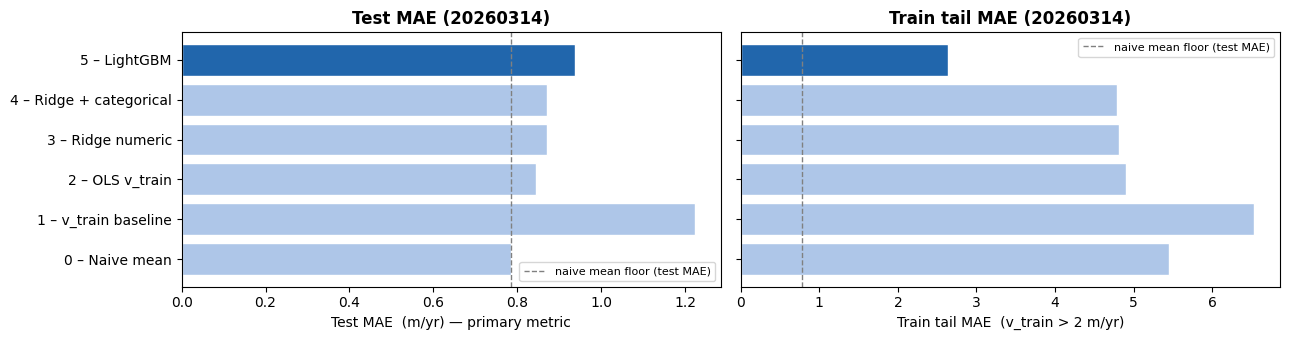

In [26]:
summary = pd.DataFrame(RESULTS).T
cols_ordered = [
    'test_mae', 'test_rmse', 'test_tail_mae',
    'train_mae', 'train_rmse', 'train_tail_mae',
    'test_r2', 'train_r2',
]
summary = summary[cols_ordered]

print(f'\n=== Model comparison – {EXPERIMENT} feature set ===')
display(summary.round(4).style
        .background_gradient(subset=['test_mae'],       cmap='RdYlGn_r')
        .background_gradient(subset=['test_tail_mae'],  cmap='RdYlGn_r')
        .background_gradient(subset=['train_tail_mae'], cmap='RdYlGn_r')
        .background_gradient(subset=['test_r2'],        cmap='RdYlGn')
        .format('{:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
for ax, metric, label in [
    (axes[0], 'test_mae',       'Test MAE  (m/yr) — primary metric'),
    (axes[1], 'train_tail_mae', 'Train tail MAE  (v_train > 2 m/yr)'),
]:
    colors = ['#2166ac' if 'LightGBM' in n else '#aec6e8' for n in summary.index]
    ax.barh(summary.index, summary[metric], color=colors, edgecolor='white')
    ax.axvline(summary.loc['0 – Naive mean', 'test_mae'], color='grey',
               linestyle='--', lw=1, label='naive mean floor (test MAE)')
    ax.set_xlabel(label)
    ax.invert_yaxis()
    ax.legend(fontsize=8)

axes[0].set_title(f'Test MAE ({EXPERIMENT})', fontweight='bold')
axes[1].set_title(f'Train tail MAE ({EXPERIMENT})', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Feature importance (LightGBM)

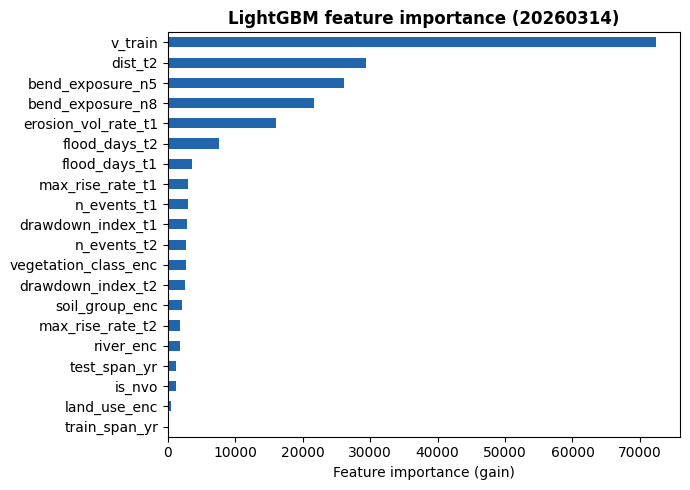

In [27]:
fi = (pd.Series(lgb_model.feature_importance(importance_type='gain'), index=FEATS_LGB)
      .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(7, 5))
fi.plot.barh(ax=ax, color='#2166ac')
ax.set_xlabel('Feature importance (gain)')
ax.set_title(f'LightGBM feature importance ({EXPERIMENT})', fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Ridge coefficient plot

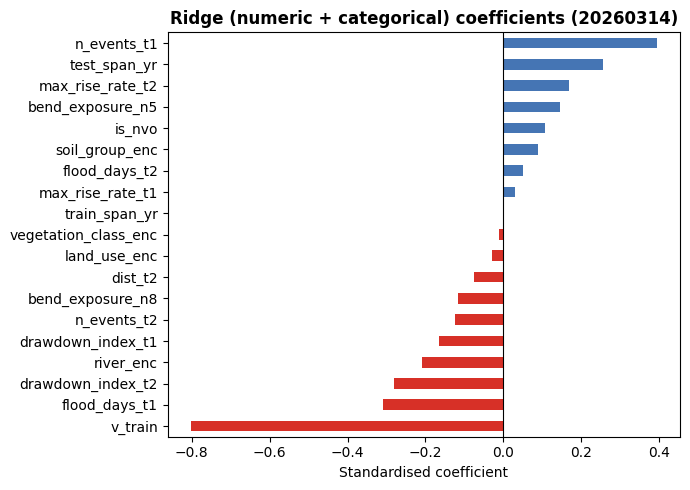

In [28]:
coef = pd.Series(ridge_cat.named_steps['ridge'].coef_, index=FEATS_4).sort_values()
colors_coef = ['#d73027' if c < 0 else '#4575b4' for c in coef]

fig, ax = plt.subplots(figsize=(7, 5))
coef.plot.barh(ax=ax, color=colors_coef)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised coefficient')
ax.set_title(f'Ridge (numeric + categorical) coefficients ({EXPERIMENT})', fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Comparison with old models (20260312)

In [29]:
from src.model.export_utils import load_model_bundle

old_bundle = load_model_bundle(PATHS.DATA_DIR / '04_model_outputs' / '20260312')
old_results = pd.DataFrame(old_bundle['results']).T

new_results = summary.copy()

compare_cols = ['test_mae', 'test_rmse', 'test_r2']
old_r = old_results[compare_cols].rename(columns=lambda c: f'{c}_old')
new_r = new_results[compare_cols].rename(columns=lambda c: f'{c}_new')

shared_models = old_r.index.intersection(new_r.index)
comparison = pd.concat([old_r.loc[shared_models], new_r.loc[shared_models]], axis=1)
comparison['test_mae_Δ'] = comparison['test_mae_new'] - comparison['test_mae_old']
comparison['test_r2_Δ']  = comparison['test_r2_new']  - comparison['test_r2_old']

print('Δ = new – old   (negative MAE delta = improvement)')
display(comparison[['test_mae_old', 'test_mae_new', 'test_mae_Δ',
                     'test_r2_old',  'test_r2_new',  'test_r2_Δ']].round(4)
        .style.background_gradient(subset=['test_mae_Δ'], cmap='RdYlGn_r')
               .background_gradient(subset=['test_r2_Δ'],  cmap='RdYlGn')
               .format('{:.4f}'))

Δ = new – old   (negative MAE delta = improvement)


,test_mae_old,test_mae_new,test_mae_Δ,test_r2_old,test_r2_new,test_r2_Δ
0 – Naive mean,0.7843,0.7843,0.0000,-0.0000,-0.0000,0.0000
1 – v_train baseline,1.2240,1.2240,0.0000,-1.1850,-1.1850,0.0000
2 – OLS v_train,0.8447,0.8447,0.0000,0.0979,0.0979,0.0000
3 – Ridge numeric,0.8448,0.8718,0.0270,0.1285,0.1113,-0.0172
4 – Ridge + categorical,0.8506,0.8717,0.0211,0.1371,0.1216,-0.0154
5 – LightGBM,0.9360,0.9365,0.0005,0.1186,0.1032,-0.0155


## 14. Save models to `04_model_outputs/20260314/`

In [30]:
OUTPUT_DIR = PATHS.DATA_DIR / '04_model_outputs' / EXPERIMENT

config = dict(
    TARGET=TARGET,
    FEATS_2=FEATS_2,
    FEATS_3=FEATS_3,
    FEATS_4=FEATS_4,
    FEATS_LGB=FEATS_LGB,
    CAT_FEATS=CAT_FEATS,
)

saved = save_model_bundle(
    path=OUTPUT_DIR,
    models={
        'ols':       ols_vt,
        'ridge_num': ridge_num,
        'ridge_cat': ridge_cat,
        'lgb':       lgb_model,
    },
    config=config,
    results=RESULTS,
)

print(f'Models saved to: {saved}')
for f in sorted(saved.iterdir()):
    print(f'  {f.name:40s}  {f.stat().st_size / 1e3:>8.1f} KB')

Models saved to: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/04_model_outputs/20260314
  20260315_model_results                    184660.0 KB
  20260315_model_results.gpkg               184660.0 KB
  bundle.joblib                                  1.4 KB
  model_lgb.joblib                            1437.2 KB
  model_ols.joblib                               0.6 KB
  model_ridge_cat.joblib                         1.6 KB
  model_ridge_num.joblib                         1.5 KB
  wocu_lgb_predictions_20260314 2.gpkg-shm      32.8 KB
  wocu_lgb_predictions_20260314 2.gpkg-wal       0.0 KB
  wocu_lgb_predictions_20260314.gpkg        184660.0 KB
